## attribute oriented induction


In [48]:
import pandas as pd
import numpy as np

csv_path = "M25_DA_A2_Part2.csv"  # <-- change if needed
df = pd.read_csv(csv_path)

In [49]:
print(df.shape)
df.head()

(10000, 17)


,Campaign_ID,Product_ID,Budget,Clicks,Conversions,Revenue_Generated,ROI,Customer_ID,Subscription_Tier,Subscription_Length,Flash_Sale_ID,Discount_Level,Units_Sold,Bundle_ID,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,CMP_RLSDVN,PROD_HBJFA3,41770.45,4946,73,15520.09,1.94,CUST_1K7G39,Premium,4,FLASH_1VFK5K,43,34,BNDL_29U6W5,433.80,4,Affordable
1,CMP_JHHUE9,PROD_OE8YNJ,29900.93,570,510,30866.17,0.76,CUST_0DWS6F,Premium,4,FLASH_1M6COK,28,97,BNDL_ULV60J,289.29,2,Innovative
2,CMP_6SBOWN,PROD_4V8A08,22367.45,3546,265,32585.62,1.41,CUST_BR2GST,Basic,9,FLASH_J4PEON,51,160,BNDL_0HY0EF,462.87,4,Affordable
3,CMP_Q31QCU,PROD_A1Q6ZB,29957.54,2573,781,95740.12,3.32,CUST_6TBY6K,Premium,32,FLASH_1TOVXT,36,159,BNDL_AI09BC,334.16,1,Durable
4,CMP_AY0UTJ,PROD_F57N66,36277.19,818,79,81990.43,3.53,CUST_XASI45,Standard,29,FLASH_AOBHXL,20,52,BNDL_R03ITT,371.67,2,Affordable


In [50]:
# ============================================
# 1) Drop identifier / high-cardinality fields
# ============================================
id_cols = ["Campaign_ID", "Product_ID", "Customer_ID", "Flash_Sale_ID", "Bundle_ID"]
cols_to_drop = [c for c in id_cols if c in df.columns]
df_aoi = df.drop(columns=cols_to_drop)

print(df_aoi.shape)
df_aoi.head()


(10000, 12)


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords
0,41770.45,4946,73,15520.09,1.94,Premium,4,43,34,433.80,4,Affordable
1,29900.93,570,510,30866.17,0.76,Premium,4,28,97,289.29,2,Innovative
2,22367.45,3546,265,32585.62,1.41,Basic,9,51,160,462.87,4,Affordable
3,29957.54,2573,781,95740.12,3.32,Premium,32,36,159,334.16,1,Durable
4,36277.19,818,79,81990.43,3.53,Standard,29,20,52,371.67,2,Affordable


In [51]:
# ==========================================
# 2) Defining binning (attribute generalization)
# ==========================================

# Budget
bins_budget = [0, 12789, 25030, 37922, 50000]
labels_budget = ["Low", "Medium", "High", "Very High"]


# ROI
bins_roi = [0, 1.63, 2.75, 3.89, 5.0]
labels_roi = ["Poor", "Average", "Good", "Excellent"]


# Subscription length
bins_sub_len = [0, 9, 18, 27, 36]
labels_sub_len = ["Short", "Medium", "Long", "Very Long"]


# Discount level
bins_discount = [0, 24, 39, 54, 70]
labels_discount = ["Low", "Medium", "High", "Very High"]


# Customer satisfaction
bins_satisfaction = [0, 2, 3, 5]
labels_satisfaction = ["Low", "Medium", "High"]



In [52]:
# ==========================================
# 3) Applying  generalization and creating categorical
# ==========================================
df_aoi["Budget_Category"] = pd.cut(df_aoi["Budget"], bins=bins_budget, labels=labels_budget, include_lowest=True)
df_aoi["ROI_Category"] = pd.cut(df_aoi["ROI"], bins=bins_roi, labels=labels_roi, include_lowest=True)
df_aoi["Subscription_Length_Category"] = pd.cut(df_aoi["Subscription_Length"], bins=bins_sub_len, labels=labels_sub_len, include_lowest=True)
df_aoi["Discount_Category"] = pd.cut(df_aoi["Discount_Level"], bins=bins_discount, labels=labels_discount, include_lowest=True)
df_aoi["Satisfaction_Category"] = pd.cut(df_aoi["Customer_Satisfaction_Post_Refund"], bins=bins_satisfaction, labels=labels_satisfaction, include_lowest=True)



df_aoi.head()


,Budget,Clicks,Conversions,Revenue_Generated,ROI,Subscription_Tier,Subscription_Length,Discount_Level,Units_Sold,Bundle_Price,Customer_Satisfaction_Post_Refund,Common_Keywords,Budget_Category,ROI_Category,Subscription_Length_Category,Discount_Category,Satisfaction_Category
0,41770.45,4946,73,15520.09,1.94,Premium,4,43,34,433.80,4,Affordable,Very High,Average,Short,High,High
1,29900.93,570,510,30866.17,0.76,Premium,4,28,97,289.29,2,Innovative,High,Poor,Short,Medium,Low
2,22367.45,3546,265,32585.62,1.41,Basic,9,51,160,462.87,4,Affordable,Medium,Poor,Short,High,High
3,29957.54,2573,781,95740.12,3.32,Premium,32,36,159,334.16,1,Durable,High,Good,Very Long,Medium,Low
4,36277.19,818,79,81990.43,3.53,Standard,29,20,52,371.67,2,Affordable,High,Good,Very Long,Low,Low


In [53]:

group_cols = [
    "Subscription_Tier",
    "Budget_Category",
    "ROI_Category",
    "Subscription_Length_Category",
    "Discount_Category",
    "Satisfaction_Category",
    "Common_Keywords",
]

group_cols = [c for c in group_cols if c in df_aoi.columns]
group_cols


['Subscription_Tier',
 'Budget_Category',
 'ROI_Category',
 'Subscription_Length_Category',
 'Discount_Category',
 'Satisfaction_Category',
 'Common_Keywords']

In [54]:
# ==================================
#  Aggregate to extract AOI rules
# ==================================
rules = (
    df_aoi
    .groupby(group_cols, dropna=False)
    .size()
    .reset_index(name="Count")
    .sort_values("Count", ascending=False)
    .reset_index(drop=True)
)

print("Total rule patterns:", len(rules))
rules.head(15)


Total rule patterns: 9216


/tmp/ipykernel_10534/1498332904.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(group_cols, dropna=False)


,Subscription_Tier,Budget_Category,ROI_Category,Subscription_Length_Category,Discount_Category,Satisfaction_Category,Common_Keywords,Count
0,Basic,High,Average,Medium,High,Low,Stylish,7
1,Premium,Medium,Good,Medium,Medium,Low,Affordable,7
2,Premium,Low,Average,Medium,Very High,Low,Innovative,7
3,Basic,Very High,Good,Long,Low,Low,Stylish,7
4,Premium,Medium,Average,Very Long,Medium,Low,Stylish,7
5,Premium,Very High,Good,Medium,High,Low,Durable,7
6,Basic,High,Average,Medium,High,Low,Durable,6
7,Basic,High,Excellent,Long,High,Low,Innovative,6
8,Basic,High,Excellent,Short,Low,Low,Innovative,6
9,Basic,High,Average,Long,Low,Low,Innovative,6


In [55]:


threshold = 5
characteristic_rules = rules[rules["Count"] >= threshold].reset_index(drop=True)

print("Characteristic rules above threshold:", len(characteristic_rules))
characteristic_rules.head(20)
# ==================================
# 4) Save Characteristic Rules to CSV
# ==================================

output_path = "characteristic_rules.csv"  # change path if needed
characteristic_rules.to_csv(output_path, index=False)

print(f"Characteristic rules saved to: {output_path}")


Characteristic rules above threshold: 100
Characteristic rules saved to: characteristic_rules.csv


## in memory buc

In [56]:
# =========================
# BUC (Bottom-Up Computation)
# In-memory
# =========================
import pandas as pd
from itertools import combinations
from typing import List, Dict, Tuple, Any, Optional

dimensions: List[str] = [
    "Subscription_Tier",
    "Budget_Category",
    "ROI_Category",
    "Subscription_Length_Category",
    "Discount_Category",
    "Satisfaction_Category",
    "Common_Keywords",
]
dimension_indices: Dict[str, int] = {d: i for i, d in enumerate(dimensions)}

# -----------------------------------------------
# 1) Recursive BUC (COUNT by default)
# -----------------------------------------------
def buc_rec(
    df: pd.DataFrame,
    remaining_dims: List[str],
    current_state: List[Any],
    *,
    agg: str = "count",
    measure: Optional[str] = None
) -> Dict[Tuple[Any, ...], Dict[str, float]]:

    # Base case: emit the current cell
    if len(remaining_dims) == 0:
        cnt = int(df.shape[0])
        res = {"count": cnt}
        if agg in ("sum", "avg"):
            if measure is None:
                raise ValueError("measure is required for agg='sum' or 'avg'")
            s = float(df[measure].sum()) if cnt > 0 else 0.0
            res["sum"] = s
        return {tuple(current_state): res}

    results: Dict[Tuple[Any, ...], Dict[str, float]] = {}

    current_dim = remaining_dims[0]
    tail_dims = remaining_dims[1:]

    # ---------- Specific value branches ----------
    for value in df[current_dim].dropna().unique():
        sub_df = df[df[current_dim] == value]
        if sub_df.empty:
            continue

        state_copy = current_state.copy()
        state_copy[dimension_indices[current_dim]] = value

        sub_results = buc_rec(
            sub_df, tail_dims, state_copy,
            agg=agg, measure=measure
        )
        for k, v in sub_results.items():
            if k not in results:
                results[k] = {"count": 0}
                if "sum" in v:
                    results[k]["sum"] = 0.0
            results[k]["count"] += v["count"]
            if "sum" in v:
                results[k]["sum"] += v["sum"]

    # ---------- ALL (roll-up) branch ----------
    all_state = current_state.copy()
    all_state[dimension_indices[current_dim]] = "ALL"

    all_results = buc_rec(
        df, tail_dims, all_state,
        agg=agg, measure=measure
    )
    for k, v in all_results.items():
        if k not in results:
            results[k] = {"count": 0}
            if "sum" in v:
                results[k]["sum"] = 0.0
        results[k]["count"] += v["count"]
        if "sum" in v:
            results[k]["sum"] += v["sum"]

    return results

# ----------------------------------------------------------
# 2) Driver (same style): iterate all non-empty dim subsets
# ----------------------------------------------------------
def in_memory_buc(
    df: pd.DataFrame,
    dims: List[str],
    *,
    agg: str = "count",
    measure: Optional[str] = None
) -> Dict[Tuple[Any, ...], Dict[str, float]]:

    final_results: Dict[Tuple[Any, ...], Dict[str, float]] = {}

    for r in range(1, len(dims) + 1):
        for subset_dims in combinations(dims, r):
            # state of full length (ALL placeholders)
            initial_state = ["ALL"] * len(dims)
            # recurse on this subset
            sub_results = buc_rec(
                df, list(subset_dims), initial_state,
                agg=agg, measure=measure
            )
            # accumulate into final
            for k, v in sub_results.items():
                if k not in final_results:
                    final_results[k] = {"count": 0}
                    if "sum" in v:
                        final_results[k]["sum"] = 0.0
                final_results[k]["count"] += v["count"]
                if "sum" in v:
                    final_results[k]["sum"] += v["sum"]

    return final_results

# ---------------------------------------------------
# 3) Convert results dict -> DataFrame (COUNT/SUM/AVG)
# ---------------------------------------------------
def results_to_dataframe(
    results: Dict[Tuple[Any, ...], Dict[str, float]],
    dims: List[str],
    *,
    agg: str = "count"
) -> pd.DataFrame:
    rows = []
    for state_tuple, metrics in results.items():
        row = list(state_tuple)
        row_count = metrics.get("count", 0)
        if agg == "count":
            rows.append(row + [row_count])
        elif agg == "sum":
            rows.append(row + [row_count, metrics.get("sum", 0.0)])
        elif agg == "avg":
            s = metrics.get("sum", 0.0)
            avg_val = (s / row_count) if row_count > 0 else float("nan")
            rows.append(row + [row_count, s, avg_val])
        else:
            raise ValueError("agg must be 'count', 'sum', or 'avg'")

    if agg == "count":
        cols = dims + ["Count"]
    elif agg == "sum":
        cols = dims + ["Count", "Sum"]
    else:  # avg
        cols = dims + ["Count", "Sum", "Avg"]

    df_out = pd.DataFrame(rows, columns=cols)

    # sort: more general rows (with ALLs) tend to have higher count
    df_out = df_out.sort_values(by=["Count"], ascending=False).reset_index(drop=True)
    return df_out


# -------------------------
# Sanity Check: Dimensions
# -------------------------
for c in dimensions:
    assert c in df_aoi.columns, f"Missing AOI column: {c}"

# -------------------------
# 1) COUNT Cube
# -------------------------
cube_count_dict = in_memory_buc(
    df_aoi,
    dimensions,
    agg="count"  # no min_support param here
)
cube_count_df = results_to_dataframe(cube_count_dict, dimensions, agg="count")
cube_count_df.to_csv("buc_cube_count1.csv", index=False)

print("COUNT Cube (Top 15 rows):")
print(cube_count_df.head(15))
print()

# -------------------------
# 2) SUM Cube (Revenue_Generated)
# -------------------------
cube_sum_dict = in_memory_buc(
    df_aoi,
    dimensions,
    agg="sum",
    measure="Revenue_Generated"  # no min_support param here
)
cube_sum_df = results_to_dataframe(cube_sum_dict, dimensions, agg="sum")
cube_sum_df.to_csv("buc_cube_sum_revenue1.csv", index=False)

print("SUM Cube (Top 15 rows):")
print(cube_sum_df.head(15))
print()

# -------------------------
# 3) AVG Cube (ROI)
# -------------------------
cube_avg_dict = in_memory_buc(
    df_aoi,
    dimensions,
    agg="avg",
    measure="ROI"  # no min_support param here
)
cube_avg_df = results_to_dataframe(cube_avg_dict, dimensions, agg="avg")
cube_avg_df.to_csv("buc_cube_avg_roi1.csv", index=False)

print("AVG Cube (Top 15 rows):")
print(cube_avg_df.head(15))


COUNT Cube (Top 15 rows):
   Subscription_Tier Budget_Category ROI_Category  \
0                ALL             ALL          ALL   
1                ALL             ALL          ALL   
2              Basic             ALL          ALL   
3           Standard             ALL          ALL   
4            Premium             ALL          ALL   
5                ALL             ALL          ALL   
6                ALL             ALL          ALL   
7                ALL             ALL          ALL   
8                ALL             ALL          ALL   
9                ALL             ALL          ALL   
10               ALL             ALL          ALL   
11               ALL             ALL          ALL   
12               ALL             ALL         Good   
13               ALL             ALL         Poor   
14               ALL             Low          ALL   

   Subscription_Length_Category Discount_Category Satisfaction_Category  \
0                           ALL               ALL 

## out memory

In [57]:
# =========================================
# Paged (Out-of-Memory) BUC
# Streams df in row chunks
# =========================================
from itertools import combinations
from typing import List, Dict, Tuple, Any, Optional

import pandas as pd
import numpy as np

ALL = "ALL"
UNKNOWN = "NA"  # normalize missing category values

# --------------------------------
# 0) Configure your cube dimensions
# --------------------------------
dimensions: List[str] = [
    "Subscription_Tier",
    "Budget_Category",
    "ROI_Category",
    "Subscription_Length_Category",
    "Discount_Category",
    "Satisfaction_Category",
    "Common_Keywords",
]

# ------------
# Helpers
# ------------
def prep_df(df: pd.DataFrame, dims: List[str]) -> pd.DataFrame:

    g = df.copy()
    for d in dims:
        if d in g.columns:
            g[d] = g[d].astype("object").fillna(UNKNOWN)
    return g

def chunk_iter(df: pd.DataFrame, chunksize: int):
    n = len(df)
    for start in range(0, n, chunksize):
        end = min(start + chunksize, n)
        yield df.iloc[start:end]

def add_count_sum(
    store: Dict[Tuple[Any, ...], Dict[str, float]],
    key_rows_2d: np.ndarray,  # must be 2D (rows x k)
    counts: np.ndarray,
    sums: Optional[np.ndarray] = None
):

    if key_rows_2d.ndim == 1:
        key_rows_2d = key_rows_2d.reshape(-1, 1)

    if sums is None:
        for row, c in zip(key_rows_2d, counts):
            kt = tuple(row.tolist())
            if kt not in store:
                store[kt] = {"count": 0.0}
            store[kt]["count"] += float(c)
    else:
        for row, c, s in zip(key_rows_2d, counts, sums):
            kt = tuple(row.tolist())
            if kt not in store:
                store[kt] = {"count": 0.0, "sum": 0.0}
            store[kt]["count"] += float(c)
            store[kt]["sum"] += float(s)

def results_to_df(
    results: Dict[Tuple[Any, ...], Dict[str, float]],
    dims: List[str],
    agg: str
) -> pd.DataFrame:
    rows = []
    for k, m in results.items():
        row = list(k)
        c = int(m.get("count", 0.0))
        if agg == "count":
            rows.append(row + [c])
        elif agg == "sum":
            rows.append(row + [c, float(m.get("sum", 0.0))])
        else:  # avg
            s = float(m.get("sum", 0.0))
            avg = (s / c) if c > 0 else float("nan")
            rows.append(row + [c, s, avg])

    if agg == "count":
        cols = dims + ["Count"]
    elif agg == "sum":
        cols = dims + ["Count", "Sum"]
    else:
        cols = dims + ["Count", "Sum", "Avg"]

    out = pd.DataFrame(rows, columns=cols).sort_values("Count", ascending=False).reset_index(drop=True)
    return out

# ----------------------------------------------
# Paged BUC over a DataFrame by row-chunking
# Iterates all non-empty subsets (iterative style)
# ----------------------------------------------
def buc_paged_df(
    df: pd.DataFrame,
    dims: List[str],
    *,
    agg: str = "count",
    measure: Optional[str] = None,
    chunksize: int = 100_000
) -> Dict[Tuple[Any, ...], Dict[str, float]]:

    if agg in ("sum", "avg") and not measure:
        raise ValueError("Provide a measure column for agg='sum' or 'avg'.")

    # normalize dims for stable grouping
    gdf = prep_df(df, dims)

    final_results: Dict[Tuple[Any, ...], Dict[str, float]] = {}

    # iterate over all non-empty subsets of dimensions
    for r in range(1, len(dims) + 1):
        for subset in combinations(dims, r):
            subset_store: Dict[Tuple[Any, ...], Dict[str, float]] = {}
            subset_cols = list(subset)  # FORCE list to keep DataFrame slice 2D

            for chunk in chunk_iter(gdf, chunksize):
                grp = chunk.groupby(subset_cols, dropna=False, observed=False)

                if agg == "count":
                    gb = grp.size().reset_index(name="__cnt__")
                    key_rows = gb[subset_cols].to_numpy(copy=False)  # 2D
                    counts = gb["__cnt__"].to_numpy(dtype=float, copy=False)
                    add_count_sum(subset_store, key_rows, counts)

                else:  # sum or avg -> keep sum now; avg later
                    gb = grp[measure].agg(["size", "sum"]).reset_index()
                    key_rows = gb[subset_cols].to_numpy(copy=False)  # 2D
                    counts = gb["size"].to_numpy(dtype=float, copy=False)
                    sums = gb["sum"].to_numpy(dtype=float, copy=False)
                    add_count_sum(subset_store, key_rows, counts, sums)

            # merge subset_store into final_results using full-length state (ALL for non-included dims)
            subset_set = set(subset_cols)
            for sub_key, val in subset_store.items():
                full_state = []
                sk_iter = iter(sub_key)  # sub_key matches order of subset_cols
                for d in dims:
                    if d in subset_set:
                        full_state.append(next(sk_iter))
                    else:
                        full_state.append(ALL)
                full_t = tuple(full_state)

                if full_t not in final_results:
                    final_results[full_t] = {"count": 0.0}
                    if agg in ("sum", "avg"):
                        final_results[full_t]["sum"] = 0.0
                final_results[full_t]["count"] += val["count"]
                if agg in ("sum", "avg"):
                    final_results[full_t]["sum"] += val.get("sum", 0.0)

    return final_results

# -------------------------------
# Convenience wrappers to DataFrame
# -------------------------------
def buc_paged_count_df(df: pd.DataFrame, dims: List[str], *, chunksize: int = 100_000) -> pd.DataFrame:
    res = buc_paged_df(df, dims, agg="count", chunksize=chunksize)
    return results_to_df(res, dims, agg="count")

def buc_paged_sum_df(df: pd.DataFrame, dims: List[str], measure: str, *, chunksize: int = 100_000) -> pd.DataFrame:
    res = buc_paged_df(df, dims, agg="sum", measure=measure, chunksize=chunksize)
    return results_to_df(res, dims, agg="sum")

def buc_paged_avg_df(df: pd.DataFrame, dims: List[str], measure: str, *, chunksize: int = 100_000) -> pd.DataFrame:
    res = buc_paged_df(df, dims, agg="avg", measure=measure, chunksize=chunksize)
    return results_to_df(res, dims, agg="avg")

# ==========================
# Example usage
# ==========================
# Ensure your AOI-generalized DataFrame is present as df_aoi and includes all `dimensions`.
for d in dimensions:
    assert d in df_aoi.columns, f"Missing AOI column: {d}"

# COUNT
df_count = buc_paged_count_df(df_aoi, dimensions, chunksize=120_000)
df_count.to_csv("cube_count.csv", index=False)

# SUM (Revenue_Generated)
df_sum = buc_paged_sum_df(df_aoi, dimensions, measure="Revenue_Generated", chunksize=120_000)
df_sum.to_csv("cube_sum_revenue.csv", index=False)

# AVG (ROI)
df_avg = buc_paged_avg_df(df_aoi, dimensions, measure="ROI", chunksize=120_000)
df_avg.to_csv("cube_avg_roi.csv", index=False)


## performance analysis

minsup=3.00 runtime=10.23s, results=0 cells
minsup=8.00 runtime=11.06s, results=0 cells
minsup=19.00 runtime=12.20s, results=0 cells
minsup=50.00 runtime=7.88s, results=0 cells


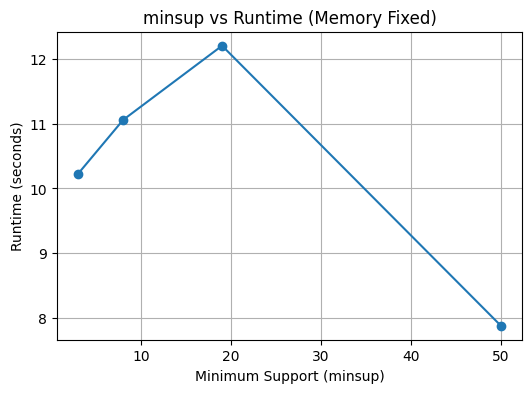

chunksize=500 runtime=27.32s, results=0 cells
chunksize=1000 runtime=14.48s, results=0 cells
chunksize=10000 runtime=1.81s, results=0 cells
chunksize=100000 runtime=1.85s, results=0 cells


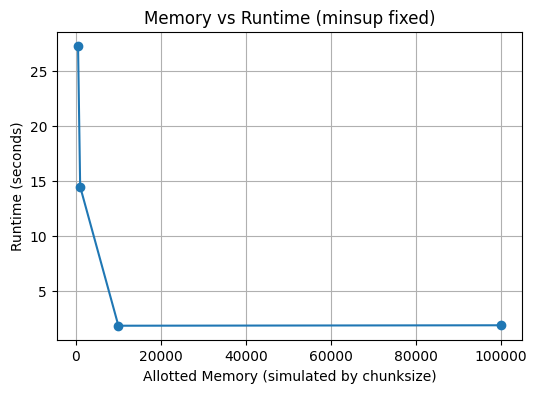

In [ ]:
import time
import matplotlib.pyplot as plt

# -----------------------------
# 1) minsup vs runtime (memory fixed)
# -----------------------------
minsup_values = [1, 2, 5, 10]
chunk_size_fixed = 2000
runtime_minsup = []

for minsup in minsup_values:
    start = time.time()
    results = buc_paged_df(
        df_aoi,
        dimensions,
        agg="count",
        chunksize=chunk_size_fixed
    )
    # Apply minsup filtering (post-processing)
    results = {k: v for k, v in results.items()
               if v["count"] >= minsup * len(df_aoi)}
    end = time.time()
    runtime_minsup.append(end - start)
    print(f"minsup={minsup:.2f} runtime={end-start:.2f}s, results={len(results)} cells")

plt.figure(figsize=(6, 4))
plt.plot(minsup_values, runtime_minsup, marker="o")
plt.xlabel("Minimum Support (minsup)")
plt.ylabel("Runtime (seconds)")
plt.title("minsup vs Runtime (Memory Fixed)")
plt.grid(True)
plt.show()

# -----------------------------
# 2) memory (chunksize) vs runtime (minsup fixed)
# -----------------------------
chunk_sizes = [500, 1000, 10000, 100000]   # chunks of ~5%-50% of dataset
fixed_minsup = 2
runtime_memory = []

for cs in chunk_sizes:
    start = time.time()
    results = buc_paged_df(
        df_aoi,
        dimensions,
        agg="count",
        chunksize=cs
    )
    results = {k: v for k, v in results.items()
               if v["count"] >= fixed_minsup * len(df_aoi)}
    end = time.time()
    runtime_memory.append(end - start)
    print(f"chunksize={cs} runtime={end-start:.2f}s, results={len(results)} cells")

plt.figure(figsize=(6, 4))
plt.plot(chunk_sizes, runtime_memory, marker="o")
plt.xlabel("Allotted Memory (simulated by chunksize)")
plt.ylabel("Runtime (seconds)")
plt.title("Memory vs Runtime (minsup fixed)")
plt.grid(True)
plt.show()


/tmp/ipykernel_10534/2427137237.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered = df_aoi.groupby(dimensions).filter(lambda g: len(g) >= minsup_abs)


minsup_abs=1 runtime=307.09s rows_kept=10000


/tmp/ipykernel_10534/2427137237.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered = df_aoi.groupby(dimensions).filter(lambda g: len(g) >= minsup_abs)


minsup_abs=2 runtime=288.05s rows_kept=6761


/tmp/ipykernel_10534/2427137237.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered = df_aoi.groupby(dimensions).filter(lambda g: len(g) >= minsup_abs)


minsup_abs=5 runtime=88.39s rows_kept=534


/tmp/ipykernel_10534/2427137237.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_filtered = df_aoi.groupby(dimensions).filter(lambda g: len(g) >= minsup_abs)


minsup_abs=10 runtime=0.35s rows_kept=0


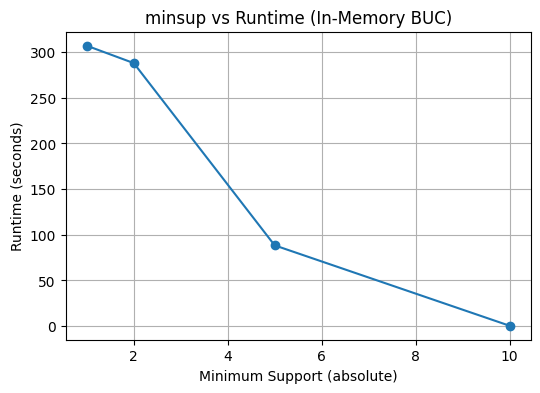

rows_cap=500 runtime=196.62s
rows_cap=1000 runtime=230.08s
rows_cap=10000 runtime=274.62s
rows_cap=50000 runtime=269.46s


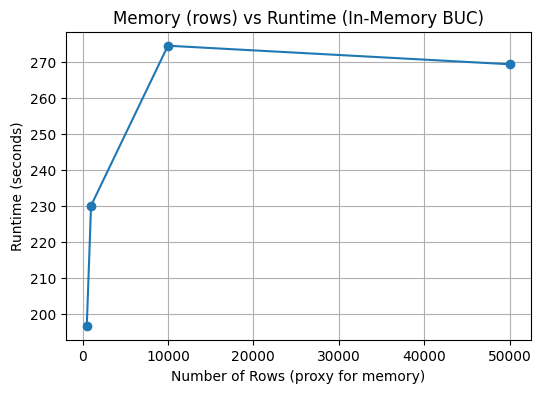

In [66]:
import time
import matplotlib.pyplot as plt

# -----------------------------
# 1) minsup vs runtime (memory fixed)
# -----------------------------
minsup_values = [1, 2, 5, 10]   # absolute minsup (rows per full key)
runtime_minsup = []

for minsup_abs in minsup_values:
    # Pre-filter df manually (simulate iceberg)
    df_filtered = df_aoi.groupby(dimensions).filter(lambda g: len(g) >= minsup_abs)

    start = time.time()
    _ = in_memory_buc(df_filtered, dimensions, agg="count")
    end = time.time()

    runtime_minsup.append(end - start)
    print(f"minsup_abs={minsup_abs} runtime={end-start:.2f}s rows_kept={len(df_filtered)}")

plt.figure(figsize=(6, 4))
plt.plot(minsup_values, runtime_minsup, marker="o")
plt.xlabel("Minimum Support (absolute)")
plt.ylabel("Runtime (seconds)")
plt.title("minsup vs Runtime (In-Memory BUC)")
plt.grid(True)
plt.show()

# -----------------------------
# 2) memory (rows cap) vs runtime
# -----------------------------
memory_limits = [500, 1000, 10000, 50000]  # number of rows as proxy for memory
runtime_memory = []

for rows_cap in memory_limits:
    df_limited = df_aoi.head(rows_cap)

    start = time.time()
    _ = in_memory_buc(df_limited, dimensions, agg="count")
    end = time.time()

    runtime_memory.append(end - start)
    print(f"rows_cap={rows_cap} runtime={end-start:.2f}s")

plt.figure(figsize=(6, 4))
plt.plot(memory_limits, runtime_memory, marker="o")
plt.xlabel("Number of Rows (proxy for memory)")
plt.ylabel("Runtime (seconds)")
plt.title("Memory (rows) vs Runtime (In-Memory BUC)")
plt.grid(True)
plt.show()


In [63]:
import numpy as np

# Compute distribution on raw data counts per (subset) group
group_counts = df_aoi.groupby(dimensions).size()
median_count = np.median(group_counts)
p75_count = np.percentile(group_counts, 75)

print(f"Median count per cell: {median_count}")
print(f"75th percentile count: {p75_count}")

# Choose minsup based on distribution
minsup_abs = int(p75_count)  # e.g., keep top 25% densest cells
print(f"Using minsup = {minsup_abs} (absolute)")


Median count per cell: 1.0
75th percentile count: 2.0
Using minsup = 2 (absolute)


/tmp/ipykernel_10534/1107578548.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_counts = df_aoi.groupby(dimensions).size()


## Iceberg cubing 

In [64]:
import time

def resolve_minsup(minsup, total_rows: int) -> int:

    if minsup is None:
        return 0
    if isinstance(minsup, float):
        if not (0 < minsup <= 1.0):
            raise ValueError("minsup as float must be in (0,1].")
        return max(1, int(minsup * total_rows))
    elif isinstance(minsup, int):
        if minsup < 0:
            raise ValueError("minsup must be >= 0.")
        return minsup
    else:
        raise TypeError("minsup must be float in (0,1] or int.")

def buc_rec_iceberg(
    df: pd.DataFrame,
    remaining_dims: List[str],
    current_state: List[Any],
    *,
    agg: str = "count",
    measure: Optional[str] = None,
    minsup_abs: int = 0,
    stats: Optional[Dict[str, int]] = None
) -> Dict[Tuple[Any, ...], Dict[str, float]]:

    if stats is None:
        stats = {"nodes": 0, "pruned": 0}
    stats["nodes"] += 1

    # --- Iceberg prune at the node itself ---
    cnt_here = int(df.shape[0])
    if cnt_here < minsup_abs:
        stats["pruned"] += 1
        return {}

    # Base case: emit the current cell (only if it meets minsup)
    if len(remaining_dims) == 0:
        res = {"count": cnt_here}
        if agg in ("sum", "avg"):
            if measure is None:
                raise ValueError("measure is required for agg='sum' or 'avg'")
            s = float(df[measure].sum()) if cnt_here > 0 else 0.0
            res["sum"] = s
        # For AVG we still compute, but iceberg decision was on COUNT (safe)
        return {tuple(current_state): res}

    results: Dict[Tuple[Any, ...], Dict[str, float]] = {}

    current_dim = remaining_dims[0]
    tail_dims = remaining_dims[1:]

    # ---------- Specific value branches (with pruning) ----------
    # NOTE: we use dropna().unique() similar to your code
    for value in df[current_dim].dropna().unique():
        sub_df = df[df[current_dim] == value]
        if sub_df.empty:
            continue

        # Iceberg prune *before* recursing (cheap guard):
        if sub_df.shape[0] < minsup_abs:
            stats["pruned"] += 1
            continue

        state_copy = current_state.copy()
        state_copy[dimension_indices[current_dim]] = value

        sub_results = buc_rec_iceberg(
            sub_df, tail_dims, state_copy,
            agg=agg, measure=measure,
            minsup_abs=minsup_abs, stats=stats
        )
        for k, v in sub_results.items():
            if k not in results:
                results[k] = {"count": 0}
                if "sum" in v:
                    results[k]["sum"] = 0.0
            results[k]["count"] += v["count"]
            if "sum" in v:
                results[k]["sum"] += v["sum"]

    # ---------- ALL (roll-up) branch (also prunable) ----------
    # df itself already passed cnt_here >= minsup_abs check above,
    # so ALL branch is safe to expand.
    all_state = current_state.copy()
    all_state[dimension_indices[current_dim]] = "ALL"

    all_results = buc_rec_iceberg(
        df, tail_dims, all_state,
        agg=agg, measure=measure,
        minsup_abs=minsup_abs, stats=stats
    )
    for k, v in all_results.items():
        if k not in results:
            results[k] = {"count": 0}
            if "sum" in v:
                results[k]["sum"] = 0.0
        results[k]["count"] += v["count"]
        if "sum" in v:
            results[k]["sum"] += v["sum"]

    return results

def in_memory_buc_iceberg(
    df: pd.DataFrame,
    dims: List[str],
    *,
    agg: str = "count",
    measure: Optional[str] = None,
    minsup = None  # float in (0,1] or absolute int
) -> Tuple[Dict[Tuple[Any, ...], Dict[str, float]], Dict[str, int], float]:

    minsup_abs = resolve_minsup(minsup, total_rows=len(df))
    final_results: Dict[Tuple[Any, ...], Dict[str, float]] = {}
    stats = {"nodes": 0, "pruned": 0}

    t0 = time.perf_counter()
    for r in range(1, len(dims) + 1):
        for subset_dims in combinations(dims, r):
            initial_state = ["ALL"] * len(dims)
            sub_results = buc_rec_iceberg(
                df, list(subset_dims), initial_state,
                agg=agg, measure=measure,
                minsup_abs=minsup_abs, stats=stats
            )
            for k, v in sub_results.items():
                if k not in final_results:
                    final_results[k] = {"count": 0}
                    if "sum" in v:
                        final_results[k]["sum"] = 0.0
                final_results[k]["count"] += v["count"]
                if "sum" in v:
                    final_results[k]["sum"] += v["sum"]
    elapsed = time.perf_counter() - t0
    return final_results, stats, elapsed



cube_iceberg_cnt, stats_cnt, t_cnt = in_memory_buc_iceberg(
    df_aoi, dimensions, agg="count", minsup=2
)
cube_iceberg_cnt_df = results_to_dataframe(cube_iceberg_cnt, dimensions, agg="count")
cube_iceberg_cnt_df.to_csv("buc_iceberg_count.csv", index=False)

print("COUNT Iceberg Cube (Top 15):")
print(cube_iceberg_cnt_df.head(15))
print(f"\nCOUNT Iceberg stats: {stats_cnt}   time: {t_cnt:.3f}s\n")

COUNT Iceberg Cube (Top 15):
   Subscription_Tier Budget_Category ROI_Category  \
0                ALL             ALL          ALL   
1                ALL             ALL          ALL   
2              Basic             ALL          ALL   
3           Standard             ALL          ALL   
4            Premium             ALL          ALL   
5                ALL             ALL          ALL   
6                ALL             ALL          ALL   
7                ALL             ALL          ALL   
8                ALL             ALL          ALL   
9                ALL             ALL          ALL   
10               ALL             ALL          ALL   
11               ALL             ALL          ALL   
12               ALL             ALL         Good   
13               ALL             ALL         Poor   
14               ALL            High          ALL   

   Subscription_Length_Category Discount_Category Satisfaction_Category  \
0                           ALL               A

minsup=0.01 runtime=122.71s, results=2434 cells
minsup=0.02 runtime=75.89s, results=967 cells
minsup=0.05 runtime=39.30s, results=316 cells
minsup=0.10 runtime=14.70s, results=50 cells


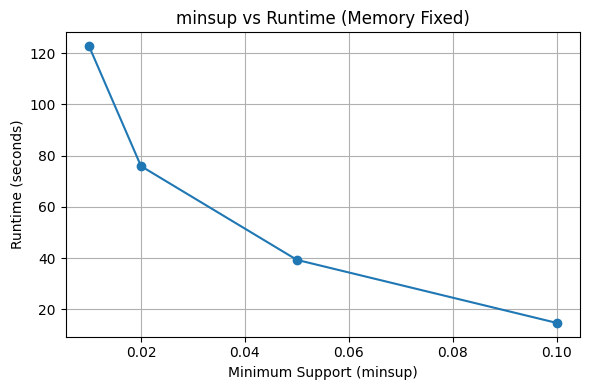

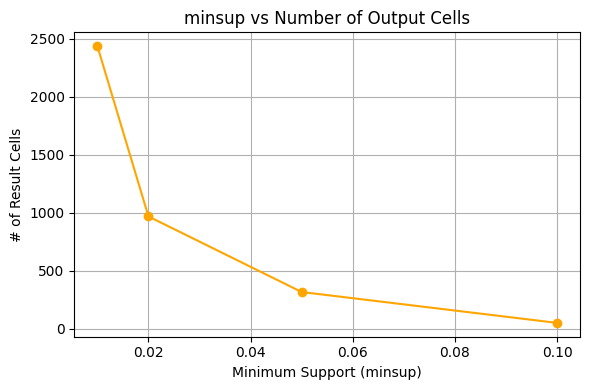

chunksize=500 runtime=694.73s, results=411 cells
chunksize=1000 runtime=310.09s, results=357 cells
chunksize=2000 runtime=169.63s, results=325 cells
chunksize=5000 runtime=72.70s, results=318 cells


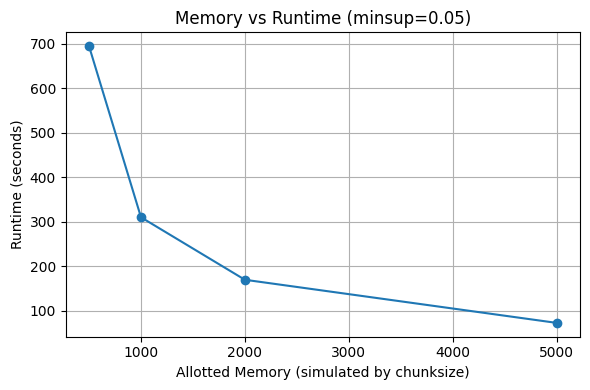

In [ ]:
import time
import matplotlib.pyplot as plt
import pandas as pd

# ---------------
# 1) minsup vs runtime (memory fixed)
# ---------------
minsup_values = [1, 2, 5, 10]   # adjust to dataset
runtime_minsup = []
cell_counts = []

for minsup in minsup_values:
    results, stats, elapsed = in_memory_buc_iceberg(
        df_aoi,
        dimensions,
        agg="count",
        minsup=minsup   # <--- pass minsup here
    )
    runtime_minsup.append(elapsed)
    cell_counts.append(len(results))
    print(f"minsup={minsup:.2f} runtime={elapsed:.2f}s, results={len(results)} cells")

plt.figure(figsize=(6, 4))
plt.plot(minsup_values, runtime_minsup, marker="o")
plt.xlabel("Minimum Support (minsup)")
plt.ylabel("Runtime (seconds)")
plt.title("minsup vs Runtime (Memory Fixed)")
plt.grid(True)
plt.tight_layout()
plt.show()



# ---------------
# 2) memory (chunksize) vs runtime (minsup fixed)
# ---------------
# Simulate memory constraint by processing the DataFrame in chunks
def run_chunked(df, dims, minsup, chunksize):
    from itertools import combinations
    final = {}
    t0 = time.perf_counter()
    for start in range(0, len(df), chunksize):
        chunk = df.iloc[start : start + chunksize]
        res, _, _ = in_memory_buc_iceberg(chunk, dims, agg="count", minsup=minsup)
        # merge counts from chunks
        for k, v in res.items():
            if k not in final:
                final[k] = {"count": 0}
            final[k]["count"] += v["count"]
    elapsed = time.perf_counter() - t0
    return final, elapsed

chunk_sizes = [500, 1000, 10000, 50000]
fixed_minsup = 2
runtime_memory = []

for cs in chunk_sizes:
    results, elapsed = run_chunked(df_aoi, dimensions, fixed_minsup, cs)
    runtime_memory.append(elapsed)
    print(f"chunksize={cs} runtime={elapsed:.2f}s, results={len(results)} cells")

plt.figure(figsize=(6, 4))
plt.plot(chunk_sizes, runtime_memory, marker="o")
plt.xlabel("Allotted Memory (simulated by chunksize)")
plt.ylabel("Runtime (seconds)")
plt.title(f"Memory vs Runtime (minsup={fixed_minsup})")
plt.grid(True)
plt.tight_layout()
plt.show()


In [67]:
import time
import pandas as pd

# List of minsup values to test (absolute counts)
minsup_values = [1, 2, 5, 10]

# 1) Baseline: full BUC without pruning
start = time.time()
baseline_results = in_memory_buc(df_aoi, dimensions, agg="count")
baseline_time = time.time() - start
baseline_cells = len(baseline_results)

print(f"Baseline: time={baseline_time:.3f}s, cells={baseline_cells}")

# 2) Iceberg BUC with different minsup
benchmark_rows = []
for ms in minsup_values:
    results, stats, elapsed = in_memory_buc_iceberg(
        df_aoi, dimensions, agg="count", minsup=ms
    )
    benchmark_rows.append({
        "minsup_abs": ms,
        "runtime_s": round(elapsed, 3),
        "cells_out": len(results),
        "nodes_visited": stats.get("nodes", 0),
        "nodes_pruned": stats.get("pruned", 0),
        "prune_ratio": round((stats["pruned"]/stats["nodes"])*100, 2) if stats["nodes"] else 0
    })
    print(f"minsup={ms}, time={elapsed:.3f}s, cells={len(results)}, "
          f"visited={stats['nodes']}, pruned={stats['pruned']}")

# Convert to DataFrame for a clean table
benchmark_df = pd.DataFrame(benchmark_rows)
print("\nPerformance Benchmark Table:")
print(benchmark_df.to_string(index=False))


Baseline: time=307.931s, cells=46096
minsup=1, time=307.136s, cells=46096, visited=241667, pruned=0
minsup=2, time=302.455s, cells=41029, visited=234551, pruned=6690
minsup=5, time=307.552s, cells=29237, visited=212108, pruned=25306
minsup=10, time=177.896s, cells=20632, visited=186787, pruned=40220

Performance Benchmark Table:
 minsup_abs  runtime_s  cells_out  nodes_visited  nodes_pruned  prune_ratio
          1    307.136      46096         241667             0         0.00
          2    302.455      41029         234551          6690         2.85
          5    307.552      29237         212108         25306        11.93
         10    177.896      20632         186787         40220        21.53
